In [1]:
import sys
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 确保 src/ 包可被导入
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root_dir)

from config import COAL_TYPES, TRAIN_DIR, TEST_DIR
from src.data   import load_labels, load_coal_spectra
from src.submit import pack_submission

import matplotlib.pyplot as plt

In [2]:
print("=" * 60)
print("Step 1: 加载标签")
label_map, aux_map = load_labels()
print(f"  标签总数: {len(label_map)}")

Step 1: 加载标签
  标签总数: 70


In [3]:
# Get one coal type for testing
coal_type = COAL_TYPES[0]
train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)

In [6]:
# get the spectra data from the loaded training data
spectra = train_data['spectra']

In [7]:
spectra[0][1].shape

(7305,)

In [8]:
def plot_libs_spectra(spectra_list, start_index=0, num_to_plot=5, overlay=False):
    """
    Plots the first N elements of a LIBS spectra list.
    
    Parameters:
    -----------
    spectra_list : list of tuples
        Each tuple must be (wavelengths_array, intensity_array)
    start_index : int, default 0
        Index of the first spectrum to visualize
    num_to_plot : int, default 5
        Number of spectra from the start of the list to visualize
    overlay : bool, default False
        If True, overlays all spectra on one plot. 
        If False, creates a vertical stack of individual subplots.
    """
    # Slice the list to get only the requested number of spectra
    to_plot = spectra_list[:num_to_plot]
    n = len(to_plot)
    
    if n == 0:
        print("The spectra list is empty.")
        return

    if overlay:
        # --- Option A: Overlay all spectra on a single plot ---
        plt.figure(figsize=(12, 6))
        for i, (wvl, inten) in enumerate(to_plot):
            plt.plot(wvl, inten, label=f"Spectrum {i+1}", alpha=0.8, lw=1)
        
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Intensity (a.u.)")
        plt.title(f"LIBS Spectra Overlay (First {n} Samples)")
        plt.legend(loc="upper right")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
        
    else:
        # --- Option B: Vertical stack of subplots (Recommended for sharp LIBS peaks) ---
        fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
        
        # Ensure axes is iterable even if n=1
        if n == 1:
            axes = [axes]
            
        for i, (wvl, inten) in enumerate(to_plot):
            axes[i].plot(wvl, inten, color="crimson", lw=1)
            axes[i].set_ylabel("Intensity")
            axes[i].set_title(f"Spectrum {i+1}", fontsize=10, loc="left", pad=2)
            axes[i].grid(True, linestyle="--", alpha=0.5)
        
        # Add the shared x-axis label at the bottom
        axes[-1].set_xlabel("Wavelength (nm)")
        fig.suptitle(f"LIBS Spectra Profiles (First {n} Samples)", fontsize=14, y=0.99)
        plt.tight_layout()
        plt.show()


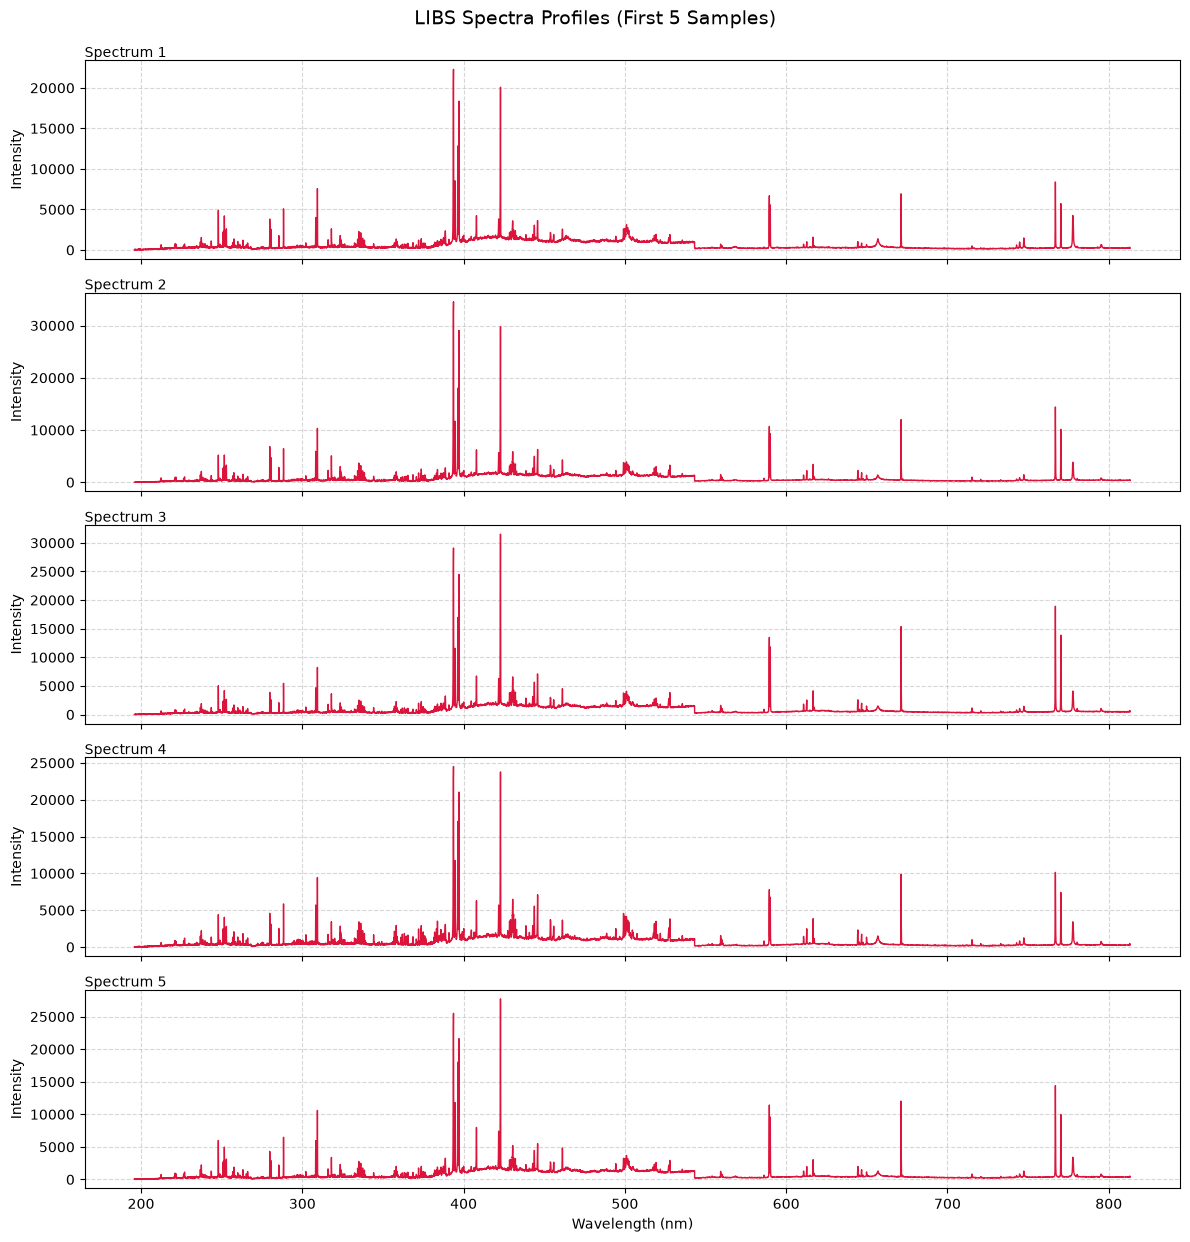

In [9]:
# Run with subplots (default)
plot_libs_spectra(spectra, start_index=0, num_to_plot=5, overlay=False)

We implement the "Asymmetric Least Squares Smoothing" by P. Eilers and H. Boelens published in 2005, which is the standard for preprocessing spectra data.

In [10]:
from scipy import sparse
from scipy.sparse.linalg import spsolve

def baseline_als(y, lam=1e6, p=0.005, niter=10):
    """
    Memory-optimized Asymmetric Least Squares baseline correction.
    
    Parameters:
    -----------
    y: 1D numpy array
        Raw spectrum array
    lam: float
        Smoothness parameter (try 1e5 to 1e8)
    p: float
        Asymmetry parameter (try 0.001 to 0.01)
    niter: int
        Number of iterations for the solver
        
    Returns:
    --------
    z: 1D numpy array
        Fitted baseline
    """
    L = len(y)
    
    # 1. Build the 2nd-order difference matrix natively in sparse format
    # Diagonals: [1, -2, 1], Offsets: [0, 1, 2]. Shape: (L-2, L)
    # This takes O(L) memory instead of O(L^2)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L-2, L))
    
    # 2. Precompute the penalty term outside the loop 
    # (Since lambda and D don't change, we only need to do this math once)
    H = lam * D.T.dot(D)
    
    # 3. Initialize weights
    w = np.ones(L)
    
    for i in range(niter):
        # Create sparse diagonal weight matrix
        W = sparse.diags(w, 0, shape=(L, L))
        
        # System to solve: (W + H) * z = w * y
        # Using CSC format makes the sparse solver faster
        Z = (W + H).tocsc()
        
        # Solve for the baseline
        z = spsolve(Z, w * y)
        
        # Update weights asymmetrically
        w = p * (y > z) + (1 - p) * (y < z)
        
    return z

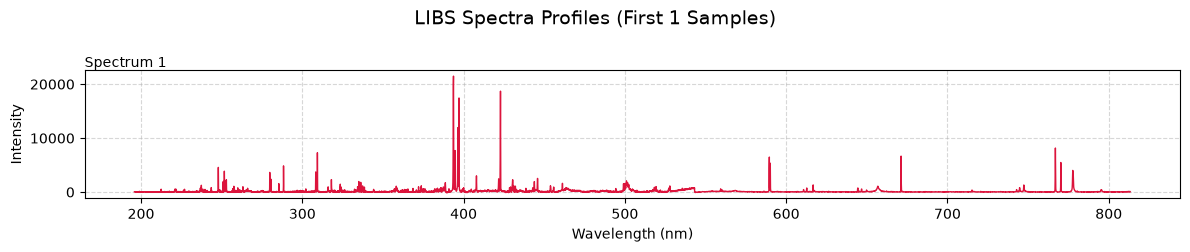

In [11]:
# try the baseline correction on the first spectrum
inten = spectra[0][1]
baseline = baseline_als(inten, lam=1e6, p=0.005)
inten_corrected = inten - baseline

plot_libs_spectra([(spectra[0][0], inten_corrected)], num_to_plot=1, overlay=False)

A note from the paper for parameter selection: "There are two parameters: $p$ for asymmetry and $\lambda$ for smoothness. Both have to be tuned to the data at hand. We found that generally $0.001 \le p \le 0.1$ is a good choice (for a signal with positive peaks) and $10^2 \le \lambda \le 10^9$, but exceptions may occur. In any case one should vary $\lambda$ on a grid that is approximately linear for $\log \lambda$."

Now we try to select the best parameters for different coal types.

In [2]:
coal_type = COAL_TYPES[0]
train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)
print(f"Loaded {len(train_data['spectra'])} spectra for coal type '{coal_type}'.")

NameError: name 'label_map' is not defined

In [ ]:
# Fix p and iteratrue through lambda
p = 0.005
lam_values = [1e2 * (10 ** i) for i in range(8)]  # Generate lambda values from 1e2 to 1e9
param_list = [(lam, p) for lam in lam_values]

[(100.0, 0.005),
 (1000.0, 0.005),
 (10000.0, 0.005),
 (100000.0, 0.005),
 (1000000.0, 0.005),
 (10000000.0, 0.005),
 (100000000.0, 0.005),
 (1000000000.0, 0.005)]

In [30]:
from src.model  import train_coal_model, predict_coal
best_lam = None
min_rmse = float('inf')
for param in param_list:
    print("=" * 60)
    print(f"Training model with ALS parameters: lambda={param[0]}, p={param[1]}")
    model_dict = train_coal_model(coal_type, train_data, als_param=param)
    if model_dict['cv_rmse'] < min_rmse:
        min_rmse = model_dict['cv_rmse']
        best_lam = param[0]
print(f"\nBest ALS lambda found: lambda={best_lam} with CV RMSE={min_rmse:.4f}")

Training model with ALS parameters: lambda=10000.0, p=0.001

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 225.03 ± 72.47
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.002

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 238.34 ± 78.16
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.003

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 176.85 ± 68.50
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.004

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 159.10 ± 68.67
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.005

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 163.26 ± 75.48
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.006

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 185.02 ± 74.21
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.00

In [ ]:
lam = best_lam
p_list = [0.001 + 0.001 * i for i in range(10)]  # Generate p values from 0.001 to 0.01
param_list = [(lam, p) for p in p_list]


[(10000.0, 0.001),
 (10000.0, 0.002),
 (10000.0, 0.003),
 (10000.0, 0.004),
 (10000.0, 0.005),
 (10000.0, 0.006),
 (10000.0, 0.007),
 (10000.0, 0.008),
 (10000.0, 0.009000000000000001),
 (10000.0, 0.010000000000000002)]

In [25]:
best_p = None
min_rmse = float('inf')
for param in param_list:
    print("=" * 60)
    print(f"Training model with ALS parameters: lambda={param[0]}, p={param[1]}")
    model_dict = train_coal_model(coal_type, train_data, als_param=param)
    if model_dict['cv_rmse'] < min_rmse:
        min_rmse = model_dict['cv_rmse']
        best_p = param[1]
print(f"\nBest ALS p found: p={best_p} with CV RMSE={min_rmse:.4f}")

Training model with ALS parameters: lambda=10000.0, p=0.001

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 225.03 ± 72.47
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.002

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 238.34 ± 78.16
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.003

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 176.85 ± 68.50
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.004

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 159.10 ± 68.67
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.005

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 163.26 ± 75.48
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.006

  [赵固一矿豫焦末煤]  11批次  140条光谱  Q=4708~6143
    Stage2 CV-RMSE: 185.02 ± 74.21
    最优正则化 alpha: 1.0
Training model with ALS parameters: lambda=10000.0, p=0.00

In [4]:
def find_als_params(coal_type, train_data, lam_values=None, p_values=None):
    """
    Finds the best ALS parameters (lambda and p) for baseline correction
    by performing a grid search over the provided ranges.
    
    Parameters:
    -----------
    coal_type : str
        The type of coal being analyzed.
    train_data : dict
        The training data containing spectra and labels.
    lam_values : list of float, optional
        List of lambda values to test. If None, defaults to [1e2 * (10 ** i) for i in range(8)].
    p_values : list of float, optional
        List of p values to test. If None, defaults to [0.001 + 0.001 * i for i in range(10)].
        
    Returns:
    --------
    best_params : tuple
        The best (lambda, p) pair found during the search.
    best_dict : dict
        The model dictionary corresponding to the best parameters.
    """

    train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)
    
    if lam_values is None:
        lam_values = [1e2 * (10 ** i) for i in range(8)]  # Default lambda values from 1e2 to 1e9
    if p_values is None:
        p_values = [0.001 + 0.001 * i for i in range(10)]  # Default p values from 0.001 to 0.01
    
    # Step 1: Find the best lambda with fixed p
    param_list = [(lam, 0.005) for lam in lam_values]
    best_lam = None
    min_rmse = float('inf')
    for param in param_list:
        print(f"Training model with ALS parameters: lambda={param[0]}, p={param[1]}")
        model_dict = train_coal_model(coal_type, train_data, als_param=param, param_search=True)
        if model_dict['cv_rmse'] < min_rmse:
            min_rmse = model_dict['cv_rmse']
            best_lam = param[0]

    # Step 2: Find the best p with the best lambda
    param_list = [(best_lam, p) for p in p_values]
    best_p = None
    min_rmse = float('inf')
    best_dict = None
    for param in param_list:
        print(f"Training model with ALS parameters: lambda={param[0]}, p={param[1]}")
        model_dict = train_coal_model(coal_type, train_data, als_param=param, param_search=True)
        if model_dict['cv_rmse'] < min_rmse:
            min_rmse = model_dict['cv_rmse']
            best_p = param[1]
            best_dict = model_dict
    print(f"\nBest ALS parameters found for coal {coal_type}:")
    print(f"  lambda = {best_lam}, p = {best_p} with CV RMSE = {min_rmse:.4f}")

    return best_lam, best_p, best_dict


In [5]:
from src.model  import train_coal_model
models     = {}
cv_results = {}
als_params = {}
for coal_type in COAL_TYPES:
    print(f"\n{'=' * 60}")
    print(f"Finding best ALS parameters for coal type: {coal_type}")
    lam, p, best_dict = find_als_params(coal_type, train_data)
    als_params[coal_type] = (lam, p)
    models[coal_type] = best_dict
    cv_results[coal_type] = best_dict['cv_rmse']

global_cv_rmse = float(np.mean(list(cv_results.values())))
print(f"\n{'=' * 60}")
print(f"全局 CV-RMSE: {global_cv_rmse:.2f}")


Finding best ALS parameters for coal type: 赵固一矿豫焦末煤
Training model with ALS parameters: lambda=100.0, p=0.005
Training model with ALS parameters: lambda=1000.0, p=0.005
Training model with ALS parameters: lambda=10000.0, p=0.005
Training model with ALS parameters: lambda=100000.0, p=0.005
Training model with ALS parameters: lambda=1000000.0, p=0.005
Training model with ALS parameters: lambda=10000000.0, p=0.005
Training model with ALS parameters: lambda=100000000.0, p=0.005
Training model with ALS parameters: lambda=1000000000.0, p=0.005
Training model with ALS parameters: lambda=1000000000.0, p=0.001
Training model with ALS parameters: lambda=1000000000.0, p=0.002
Training model with ALS parameters: lambda=1000000000.0, p=0.003
Training model with ALS parameters: lambda=1000000000.0, p=0.004
Training model with ALS parameters: lambda=1000000000.0, p=0.005
Training model with ALS parameters: lambda=1000000000.0, p=0.006
Training model with ALS parameters: lambda=1000000000.0, p=0.007


In [6]:
from src.model  import predict_coal
print("\n" + "=" * 60)
print("Step 3: 测试集推理")

all_preds = {}
for coal_type in COAL_TYPES:
    if coal_type not in models:
        continue
    test_data = load_coal_spectra(TEST_DIR, coal_type, label_map=None, aux_map=None)
    if test_data is None or len(test_data['spectra']) == 0:
        print(f"  [{coal_type}] 无测试数据")
        continue
    bp = predict_coal(coal_type, test_data, models[coal_type], als_param=als_params[coal_type])
    all_preds.update(bp)

print("\n  预测结果:")
for name, pred in sorted(all_preds.items()):
    print(f"    {name}: {pred:.2f}")


Step 3: 测试集推理

  预测结果:
    中马矿中煤矿12月27日: 3468.26
    中马矿中煤矿12月28日: 3319.07
    中马矿中煤矿12月29日: 3383.03
    中马矿中煤矿12月30日: 3262.62
    中马矿中煤矿12月31日: 3512.54
    九里山矿中煤矿12月3日: 3815.30
    九里山矿中煤矿12月4日: 3910.87
    九里山矿中煤矿12月5日: 3865.42
    九里山矿中煤矿12月6日: 3632.51
    九里山矿中煤矿12月7日: 3710.53
    九里山矿中煤矿12月9日: 3627.70
    煤场混煤12月11日: 4161.99
    煤场混煤12月12日: 4006.20
    煤场混煤12月17日: 4036.01
    煤场混煤12月20日: 3937.46
    煤场混煤12月21日: 3950.84
    煤场混煤12月28日: 4245.96
    煤场混煤12月4日: 4087.30
    煤场混煤12月8日: 4092.19
    煤场混煤12月9日: 4045.67
    赵固一矿豫焦末煤12月24日: 5830.95
    赵固一矿豫焦末煤12月2日: 5875.94
    赵固二矿中煤矿12月11日: 4263.76
    赵固二矿中煤矿12月12日: 4267.65
    赵固二矿中煤矿12月15日: 4285.35
    赵固二矿中煤矿12月27日: 4278.18


In [14]:
# ── Step 4: 打包提交 ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Step 4: 生成提交文件")
pack_submission(all_preds, cv_results, global_cv_rmse)
print("\n完成！提交文件在 output/submit.zip")


Step 4: 生成提交文件

  ✓ /Users/ellenying/Projects/LIBS/output/submit.csv
            名称  预测发热量_MJ_KG
  中马矿中煤矿12月27日  3410.895989
  中马矿中煤矿12月28日  3339.337818
  中马矿中煤矿12月29日  3379.291322
  中马矿中煤矿12月30日  3349.016555
  中马矿中煤矿12月31日  3515.984243
  九里山矿中煤矿12月3日  3894.913599
  九里山矿中煤矿12月4日  3970.222373
  九里山矿中煤矿12月5日  3924.054091
  九里山矿中煤矿12月6日  3671.793143
  九里山矿中煤矿12月7日  3722.884784
  九里山矿中煤矿12月9日  3591.794748
    煤场混煤12月11日  4189.204455
    煤场混煤12月12日  4006.296697
    煤场混煤12月17日  3999.340931
    煤场混煤12月20日  3944.566403
    煤场混煤12月21日  4006.789956
    煤场混煤12月28日  4229.706432
     煤场混煤12月4日  4094.934232
     煤场混煤12月8日  4087.380383
     煤场混煤12月9日  4034.703991
赵固一矿豫焦末煤12月24日  5837.864196
 赵固一矿豫焦末煤12月2日  5868.020785
 赵固二矿中煤矿12月11日  4278.364668
 赵固二矿中煤矿12月12日  4224.050926
 赵固二矿中煤矿12月15日  4290.831562
 赵固二矿中煤矿12月27日  4262.849549
  ✓ /Users/ellenying/Projects/LIBS/output/submit.zip
     内含: submit/submit.csv  +  submit/README.md

完成！提交文件在 output/submit.zip
